In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics as st
from math import sqrt



#                                                Correlation and Lineal Regression

## Introduction

In the real world , not all relationships are created equal. Correlation is a symmetrical tool, regardless which variable is mentioned first, and describes how tightly both variables cluster around hidden line. It measures the strength and direction of their bond. However, Lineal Regression goes step further, by providing a "tool" to estimate one based to another. It treats one variable as the cause (independent) and the other one as an effect (dependent), and explains how much the "effect" changes for every unit of the "cause"

If X and Y are two variables , in Correlation they are interchangeable. In Regression swapping X and Y - the result will be completely different model.

### Summary Comparison:

#### Correlation:
- -Measure strength of association
- -X and Y are symmetrical.
- -The result is always in range [-1 ; 1]

#### Lineal Regression:
- -Model/Predict the relationship
- -Y depends on X (directional)
- -The result could be any value that represents rate of change


## Part 1: Pearson Correlation coefficient

Let's start with one simple example to illustrate how Pearson correlation works using two variables.
We have data about the IQ test of students, avd the result of Statistic exam:

In [94]:
IQ_Test = [595, 520, 715, 405, 680, 490, 565, 580, 615, 435, 440, 515, 380, 510, 565]

In [95]:
Exam_results = [68, 55, 65, 42, 64, 45, 56, 59, 56, 42, 38, 50, 37, 42, 53]

In [96]:
# Data source:Красимир Калинов - Статистически методи в поведенческите и социалните науки

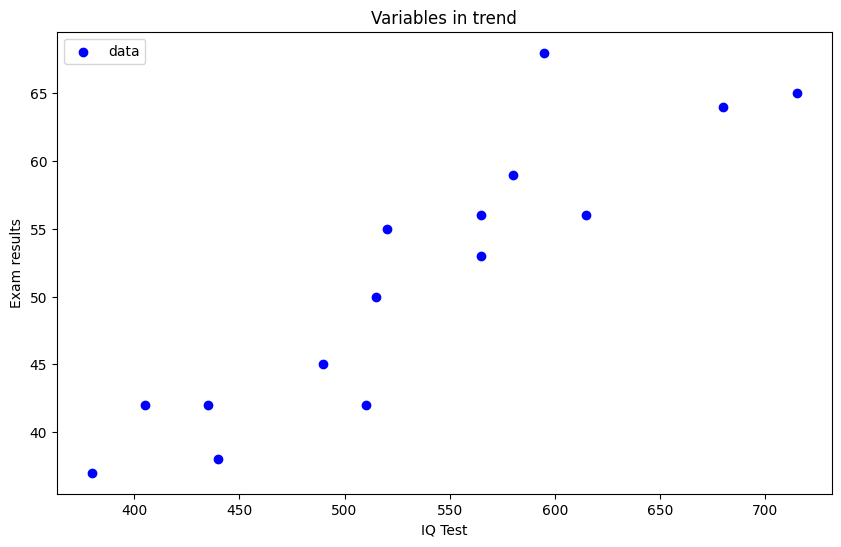

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(IQ_Test, Exam_results, c='b', label='data')
plt.xlabel("IQ Test")
plt.ylabel("Exam results")
plt.title('Variables in trend')
plt.legend(loc='upper left')
plt.grid(False)
plt.show()

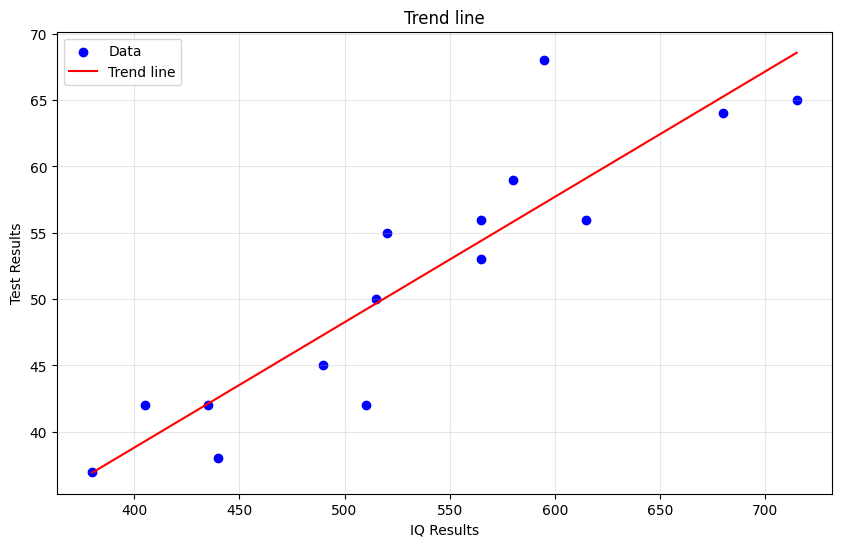

In [48]:

#Plot of Trendline
x = IQ_Test
y = Exam_results
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', label='Data')

plt.plot(sorted(x), p(sorted(x)), color='red', label='Trend line')

plt.title('Trend line')
plt.xlabel('IQ Results')
plt.ylabel('Test Results')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.show()

 The charts above shows that variables "x", and "y" clearly described uptrend direction.
 The directional joint move of two variables is measured by  Covariance  of "x" and "y", or cov(x, y).

$\bar{x}$ - Arithmetic mean

$\bar{x} = \frac{1}{n}\sum_{x=1}^{n} x_i$

$cov(x, y) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$

- When both variables increase - the covariance is positive
- When one variable increases and the other decreases - the covariance is negative
- If both variables do not vary - the covariance is zero "0".

In [49]:
# Covariance of IQ test and Exam results #

In [50]:
np.cov(IQ_Test, Exam_results)

array([[9318.57142857,  880.85714286],
       [ 880.85714286,  102.12380952]])

In [51]:
covariance_IQ_Exam = np.cov(IQ_Test, Exam_results)

##### Standard deviation:
- the differences between $x_i$ and $\bar{x}$ , $(x_i - \bar{x})$ is positive or negative, their sum is up to "0"

- when we square them (all positive) - $S^2(x) = \frac{1}{n-1}\sum_{x=1}^{n}(x_i - \bar{x})^2$

- Standard deviation - $S(x) = \sqrt{S^2(x)}$

$p_i = \frac{(x_i - \bar{x})}{S_x} \frac{(y_i - \bar{y})}{S_y}$, divided by standard deviations, we "normalize" them.

$p = \frac{1}{n}\sum{p_i} = \frac{cov(x, y)}{S_xS_y}$

$p$ - Pearson correlation coefficient

In [52]:
stdev_IQ_test = st.stdev(IQ_Test)
stdev_Exam_results = st.stdev(Exam_results)

In [53]:
stdev_IQ_test

96.53274795928803

In [54]:
stdev_Exam_results

10.105632564258881

In [55]:
#Let's continue with our example and put two variables list in matrix

In [56]:
matrix = [x, y]

In [57]:
#Transposition of matrix .

In [58]:
transposed_matrix = [list(row) for row in zip(*matrix)]

In [59]:
labels=["IQ Test", "Exam Results"]
df=pd.DataFrame(transposed_matrix, columns=labels)

In [60]:
df.describe()

,IQ Test,Exam Results
count,15.000000,15.000000
mean,534.000000,51.466667
std,96.532748,10.105633
min,380.000000,37.000000
25%,465.000000,42.000000
50%,520.000000,53.000000
75%,587.500000,57.500000
max,715.000000,68.000000


In [61]:
P_IQ_Exam = covariance_IQ_Exam/  (stdev_IQ_test * stdev_Exam_results)

In [62]:
P_IQ_Exam

array([[9.55237066, 0.9029575 ],
       [0.9029575 , 0.10468606]])

In [63]:
st.correlation(IQ_Test, Exam_results)

0.9029574959390204

In [64]:
np.corrcoef(IQ_Test, Exam_results)


array([[1.       , 0.9029575],
       [0.9029575, 1.       ]])

In [65]:
print(f"Pearson coefficient of correlation is : {np.corrcoef(IQ_Test, Exam_results)[0][1]:.4f}, positive and strong (close to 1) ")

Pearson coefficient of correlation is : 0.9030, positive and strong (close to 1) 


In [66]:
# Functions
# Using Data Frame for observed data
def data_frame(var_1:list,var_2:list):
    array = [var_1, var_2] # matrix
    transposed_array = [list(row) for row in zip(*array)] #trans. the matrix
    cols = [ 'IQ Test', ' Exam Results' ] # Labels on DataFrame columns
    df = pd.DataFrame(transposed_array, columns=cols) #
    return df

# Calculate Pearson correlation coefficient by "Statistics" module

def pearson_correlation(var_1:list,var_2:list):
    return st.correlation(var_1, var_2)

#Plot
def plot_correlated_variables(var_1:list,var_2:list):
    x = var_1
    y = var_2
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, color='purple', label='Data')
    plt.plot(sorted(x), p(sorted(x)), color='blue', label='Trend line')
    plt.title('Pearson Correlation with a trend line')
    plt.xlabel('IQ Results')
    plt.ylabel('Exam Results')
    plt.grid(True, alpha=0.5)
    plt.legend(loc='upper left')
    return plt.show()





In [67]:
data_frame(IQ_Test, Exam_results)

,IQ Test,Exam Results
0,595,68
1,520,55
2,715,65
3,405,42
4,680,64
5,490,45
6,565,56
7,580,59
8,615,56
9,435,42


In [68]:
dfr = data_frame(IQ_Test,Exam_results)

In [69]:
dfr.describe()

,IQ Test,Exam Results
count,15.000000,15.000000
mean,534.000000,51.466667
std,96.532748,10.105633
min,380.000000,37.000000
25%,465.000000,42.000000
50%,520.000000,53.000000
75%,587.500000,57.500000
max,715.000000,68.000000


In [70]:
pearson_correlation(IQ_Test, Exam_results)

0.9029574959390204

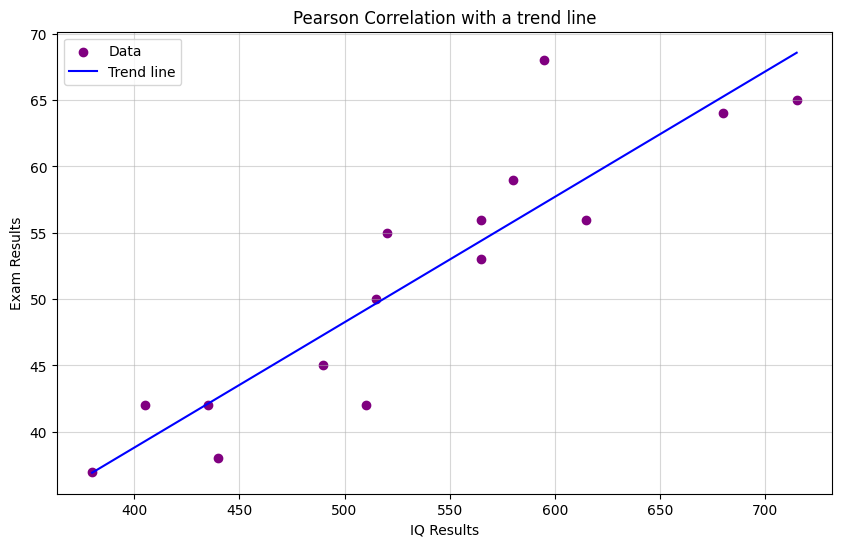

In [71]:
plot_correlated_variables(IQ_Test, Exam_results)

##  Part 2: Simple Linear Regression

The Concept: From Association to Prediction
While correlation tells us how much
 and
 move together, Regression allows us to predict
 (the dependent variable) based on
 (the independent variable).
We are looking for the equation of the "Best Fit" line:

$Y = \beta_0 + \beta_1X + \varepsilon$
- $\beta_1$ (slope) - How much (form previous example) Exam Results increases for evry one point of IQ Test increase.
- $\beta_0$ (intercept) - The predicted value of Exam Results, if IQ Test were "0"
- $\varepsilon$ - stochastic part of the model

To find the line that minimizes the distance between the data points and the line (Ordinary Least Squares), we calculate:

Slope:
- $\beta_1 = \frac{cov(x, y}{var(x)}$

Intercept:
- $\beta_0 = \bar{Y} - \beta_1\bar{X}$

In [72]:
# Calculating means of both IQ_Test and Exam_Results
mean_iq = np.mean(IQ_Test)
mean_exam = np.mean(Exam_results)

In [73]:

# Calculating b1 (slope)
# Using [0,1] from  covariance matrix and variation of X
var_iq = np.var(IQ_Test, ddof=1)
#cov_iq_exam = np.cov(IQ_Test, Exam_results)[0, 1], we already defined it as covariance_IQ_Exam = np.cov(IQ_Test, Exam_results) from previous example
covariance_IQ_Exam = covariance_IQ_Exam[0, 1]

b1 = covariance_IQ_Exam / var_iq
b0 = mean_exam - (b1 * mean_iq)

print(f"Coefficient b1 (Slope): {b1:.4f}")
print(f"Coefficient b0 (Intercept): {b0:.4f}")

Coefficient b1 (Slope): 0.0945
Coefficient b0 (Intercept): 0.9892


In [74]:
print(st.linear_regression(IQ_Test, Exam_results))

LinearRegression(slope=0.09452705810210026, intercept=0.9892176401451351)


### Prediction and estimation of the model:
- 1. Mean Squared Error (MSE): If value of MSE is lower, that means the model works good

     MSE = $\frac{1}{n}\sum(Y_{actual} - Y_{predicted})^2$

-  2. $R^2$ - Coefficient of determination: Measures how well the predictions approximate the real data points. An $R^2$ of "1" indicates that the regression prediction perfectly fits the data. If it outside the range [0 ; 1], the model fits worse.
For simple linear regression with one predictor $R^2$ equals to square of Pearson Correlation coefficient.

        $R^2$ = $r^2$

- Residuals: Measure how far the observed data points are from the alues predicted by a model
$e_i$ - residual for observation $i$

$y_i$ - actual (observed) value

$\hat{y}$ - predicted value from the model

$e_i = y_i - \hat{y}$

Meaning:
Residual = Actual - Predicted

In the regression model:
If the regression line is:

$\hat{y} = b_0 + b_1x_i$

then residuals becomes:

$e_i = y_i - (b_0 + b_1x_i)$

Where:

$b_0$ - intercept

$b_1$ - slope

$x_i$ - predictor value

In [75]:
# Generating predictive values (Predictions):
predictions = [b0 + b1 * x for x in IQ_Test]

# Calculating the errors (Residuals)
residuals = np.array(Exam_results) - np.array(predictions)

# 1. MSE
mse = np.mean(residuals**2)

# 2. R-squared
r_sq = st.correlation(IQ_Test, Exam_results)**2



For better interpretation may use RMSE (Root Mean Square Error). RMSE is a standard metric used to measure the average magnitude of prediction errors in regression models, representing the square root of the average squared differences between predicted and observed values. A lower RMSE indicates a better fit , as it measures how closely observed data points cluster around a model's predicted values :

#### Prediction:

Next step is to continue with the example by using the model to make forecast about new studens.This is the real value of Linear regression - based on analyses of the past to predict the future.

In [100]:
# Using the calculated b0 and b1

def predict_exam_score(iq_value):
    score = b0 + (b1 * iq_value)
    return score

# Example: Expected exam result of student with IQ = 600?
new_iq = 600
predicted_result = predict_exam_score(new_iq)

print(f"For IQ = {new_iq}, Model predicts exam result: {predicted_result:.2f}")


For IQ = 600, Model predicts exam result: 57.71


Assume, there are 3 new students with different IQ levels. Let's see their expected (predicted) exam results.

In [102]:
#Add values for the new students
new_students_iq = [450, 550, 650]
predictions = [predict_exam_score(iq) for iq in new_students_iq]


In [103]:
predictions

[np.float64(43.52639378609025),
 np.float64(52.97909959630027),
 np.float64(62.4318054065103)]

## Relationship between Correlation and Linear Regression

There is one important relationship between the slope (b1) and Pearson correlation coefficient:

$b_1 = r.\frac{s_y}{s_x}$


- r Pearson correlation coefficient
- $s_y$ Standard deviation of dependent variable (Exam Results)
- $s_x$ Standard deviation of independent variable (IQ Test)

 To illustrate the formula above, will use tha same example data:

In [104]:
r = pearson_correlation(IQ_Test, Exam_results) # 0.9029
sy = stdev_Exam_results               # 10.1056
sx = stdev_IQ_test                   # 96.5327

# 2. Calculating slope (b1) by correlation coefficient
b1_via_correlation = r * (sy / sx)

print(f"Correlation (r): {r:.4f}")
print(f"Slope (b1), calculated by r: {b1_via_correlation:.4f}")
print(f"Slope (b1), calculated dy OLS: {b1:.4f}")



Correlation (r): 0.9030
Slope (b1), calculated by r: 0.0945
Slope (b1), calculated dy OLS: 0.0945


Both results are
 equal.

When the slope becomes correlation?

IQ is measured by 100, but Exam results are measured by 10. This difference in scale makes direct comparison difficult. Here is usefully to standardize the data by Z-score

$ z = \frac{x - \mu}{\sigma}$


$z$ : Z-score

$x$ : Value being evaluated

$\mu$:  Population mean

$\sigma$: Population standard deviation

Standardization converts values into number of standard  deviations from the mean. After transformation both variables have mean = 0, standard deviation = 1

If $s_x$ = 1 and $s_y$ = 1,

then $b_1 = r\frac{1}{1}$, and  $b_1$ = r

In [90]:

# 1. Data standardization (Z-scores)
z_iq = [(x - np.mean(IQ_Test)) / st.stdev(IQ_Test) for x in IQ_Test]
z_exam = [(y - np.mean(Exam_results)) / st.stdev(Exam_results) for y in Exam_results]

# 2. Calculating regression over standardized data:
z_b1 = np.cov(z_iq, z_exam)[0, 1] / np.var(z_iq, ddof=1)
r_pearson = pearson_correlation(IQ_Test, Exam_results)

print(f"Correlation (r): {r_pearson:.4f}")
print(f"Slope over standardized data (Z-b1): {z_b1:.4f}")


Correlation (r): 0.9030
Slope over standardized data (Z-b1): 0.9030
Correlation (r): 0.9030
Slope over standardized data (Z-b1): 0.9030


-Finaly will define a function to complete the model, and make important conclusions:

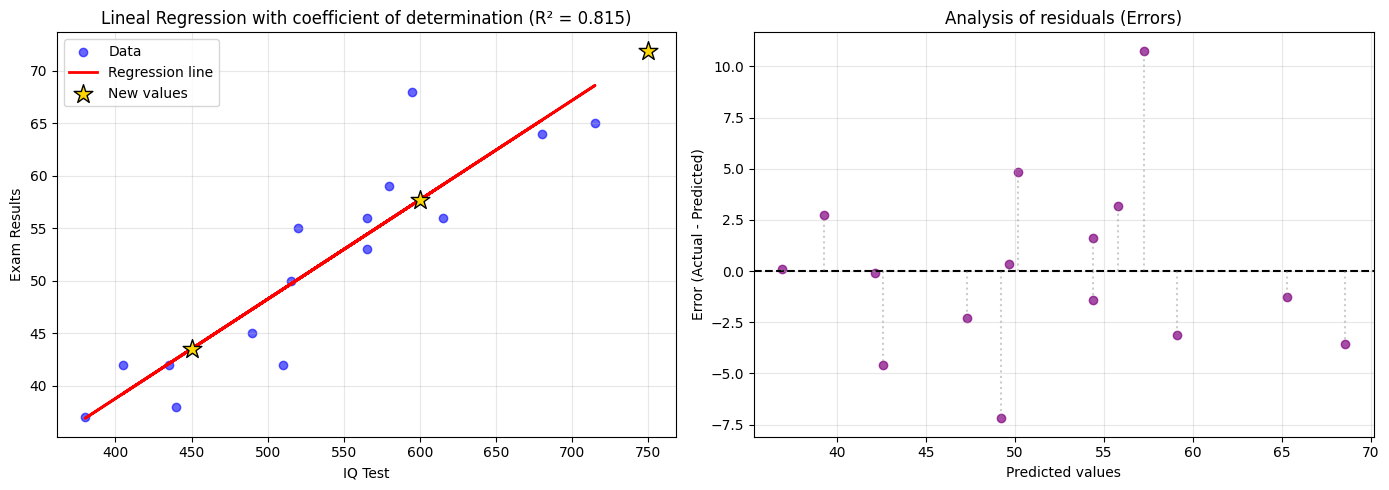

Pearson correlation coefficient (r): 0.9030
MSE: 17.60
RMSE: 4.20
Coefficient of determination (R-squared): 0.8153
Model: Y = 0.99 + 0.0945 * X


In [99]:
#Function

def simple_regression_with_residuals(x, y, new_x_points):
    # 1. Calculating of basics parameters
    n = len(x)
    r = st.correlation(x, y)
    b1 = r * (st.stdev(y) / st.stdev(x))
    b0 = np.mean(y) - (b1 * np.mean(x))
    r_squared = r**2

    # 2. Prediction and errors (residulas)
    y_pred = b0 + b1 * np.array(x)
    residuals = np.array(y) - y_pred
    new_predictions = b0 + b1 * np.array(new_x_points)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Lineal regression and predicted values
    ax1.scatter(x, y, color='blue', alpha=0.6, label='Data')
    ax1.plot(x, y_pred, color='red', linewidth=2, label='Regression line')
    ax1.scatter(new_x_points, new_predictions, color='gold', marker='*', s=200,
                edgecolor='black', label='New values', zorder=5)

    ax1.set_title(f'Lineal Regression with coefficient of determination (R² = {r**2:.3f})')
    ax1.set_xlabel('IQ Test')
    ax1.set_ylabel('Exam Results')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Residual Plot
    ax2.scatter(y_pred, residuals, color='purple', alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1.5)

    # Adding vertical lines for each error (from 0 to point)
    for i in range(n):
        ax2.vlines(y_pred[i], 0, residuals[i], color='gray', linestyle=':', alpha=0.4)

    ax2.set_title('Analysis of residuals (Errors)')
    ax2.set_xlabel('Predicted values')
    ax2.set_ylabel('Error (Actual - Predicted)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    print(f"Pearson correlation coefficient (r): {r:.4f}")
    print(f"MSE: {np.mean(residuals**2):.2f}")
    print(f"RMSE: {sqrt(mse):.2f}")
    print(f"Coefficient of determination (R-squared): {r_squared:.4f}")
    print(f"Model: Y = {b0:.2f} + {b1:.4f} * X")

# Data used
#IQ_Test = [595, 520, 715, 405, 680, 490, 565, 580, 615, 435, 440, 515, 380, 510, 565]
#Exam_results = [68, 55, 65, 42, 64, 45, 56, 59, 56, 42, 38, 50, 37, 42, 53]
#new_students = [450, 600, 750]

simple_regression_with_residuals(IQ_Test, Exam_results, new_students)


Left plot: Shows how data are arranged  according the model and where the new students (stars).

Right plot: Shows the errors (residuals). If the points are randomly distributed without clear figure around horizontal line ("0"), the model is reasonably good.

As we already calculated $R^2$ = 0.82, that means 82% of the variability in Y(Exam Results) is explained by the model, while 18% remains unexplained. MSE = 17.6 . As plot 2 shows the residuals looks randomly distributed around "0". Overall indicating the model assumptions are satisfied. The regression model provides a good fit to the data, explaining a large portion of the variability, while maintaining relatively small prediction errors.







## Conclusion:

In this article was traced the path from Pearson Correlation to Lineal Regression. The given example was as simple as possible, because the goal was to reveal the fundamental meaning of both tools. There are many  regression and correlations models , but their explanation is beyond the scope of current article.




## Summary:

- Pearson correlation ($r\approx{90}$) represents strong proportional relationship between IQ and Exam results.

- Lineal Regression give us a formula , so that we are able to predict future score with relatively good extent of accuracy ($R^2\approx{82}$)

In [92]:
#Sourses:
# - Крассимир Калинов - Статистически методи в поведенческите и социалните науки (Example Data)
# - Соня Чипева, Венелин Бошнаков - Въведение в иконометрията (Regression explanation)
# - Matplotlib documentation
# - AI assistance about advanced plots (for last plot with stars markers)
# - Wikipedia - Linear Regression (Regression explanation)